# Loan Approval Prediction

Predict whether a loan application will be approved using **Decision Tree** and **Random Forest**.

Workflow:
1. Load loan application data
2. Inspect and handle missing values
3. Encode categorical variables
4. Split data into training and testing sets
5. Train Decision Tree and Random Forest classifiers
6. Compare accuracy, precision, recall and F1-score
7. Visualize the results and Random Forest feature importance


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

os.makedirs("outputs", exist_ok=True)


In [20]:
df = pd.read_csv("data/loan_approval.csv")

print("Shape:", df.shape)
display(df.head())


Shape: (1000, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100001,Male,Yes,2,Not Graduate,No,2823,3764,261.0,360.0,1.0,Urban,Y
1,LP100002,Male,Yes,0,Graduate,No,3836,3662,339.0,360.0,1.0,Semiurban,Y
2,LP100003,Female,Yes,3+,Graduate,No,6001,183,145.0,360.0,1.0,Rural,Y
3,LP100004,Male,Yes,1,Not Graduate,No,3657,626,253.0,300.0,1.0,Rural,Y
4,LP100005,Male,Yes,0,Graduate,No,4433,611,297.0,240.0,1.0,Semiurban,Y


Missing values before preprocessing:


Credit_History       60
Dependents           50
Gender               40
Self_Employed        40
LoanAmount           40
Married              30
Loan_Amount_Term     30
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

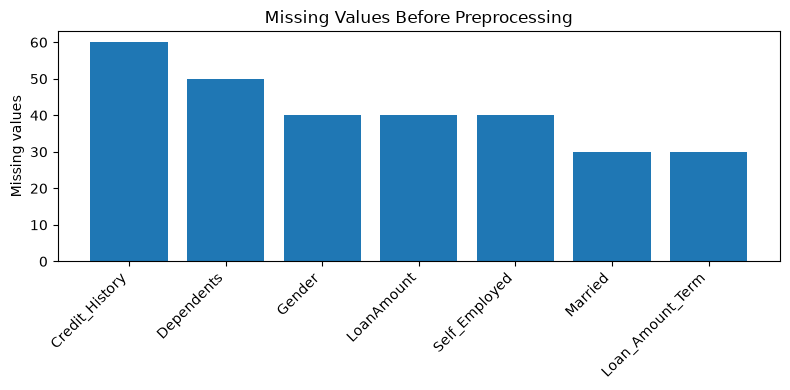

In [21]:
print("Missing values before preprocessing:")
display(df.isnull().sum().sort_values(ascending=False))

plt.figure(figsize=(8, 4))
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.bar(missing.index, missing.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing values")
plt.title("Missing Values Before Preprocessing")
plt.tight_layout()
plt.savefig("outputs/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()


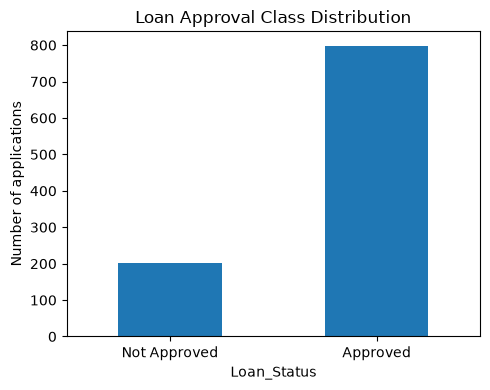

In [22]:
plt.figure(figsize=(5, 4))
df["Loan_Status"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Not Approved", "Approved"], rotation=0)
plt.ylabel("Number of applications")
plt.title("Loan Approval Class Distribution")
plt.tight_layout()
plt.savefig("outputs/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [23]:
X = df.drop(columns=["Loan_Status", "Loan_ID"])
y = df["Loan_Status"].map({"N": 0, "Y": 1})

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numeric features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


C:\Users\jayra\AppData\Local\Temp\ipykernel_74228\2906148802.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [24]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=8, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    )
}

results = {}
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0)
    }
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).T
display(results_df.round(3))


,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.785,0.838,0.906,0.871
Random Forest,0.790,0.828,0.931,0.876


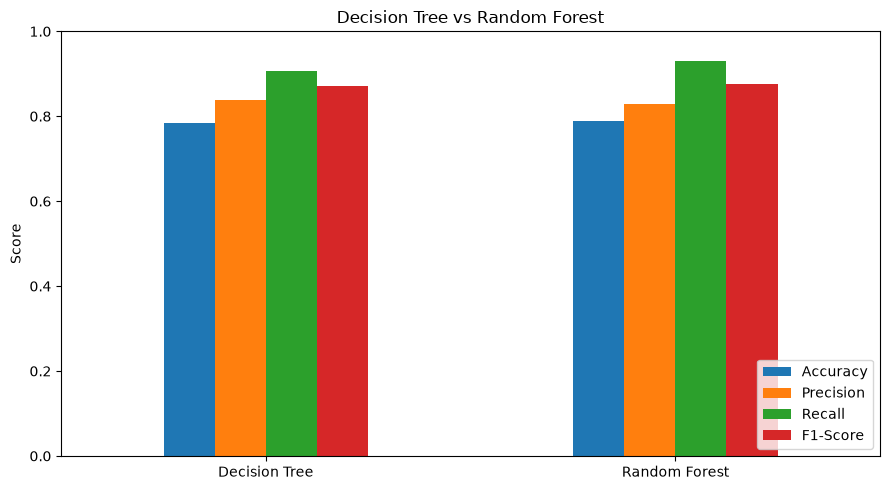

In [25]:
ax = results_df.plot(kind="bar", figsize=(9, 5))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Decision Tree vs Random Forest")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


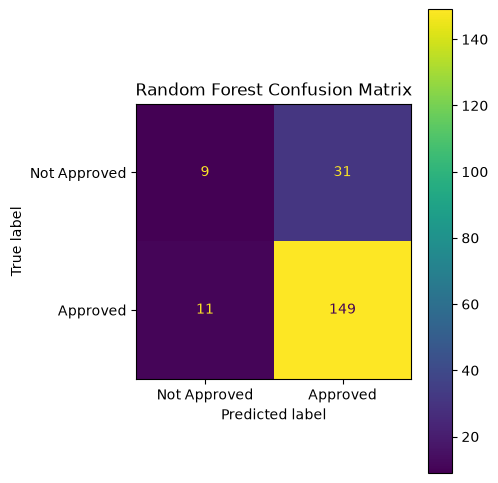

In [26]:
rf_pipe = trained_pipelines["Random Forest"]
rf_pred = rf_pipe.predict(X_test)

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Approved", "Approved"]
)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format="d")
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


,Feature,Importance
4,num__Credit_History,0.456206
0,num__ApplicantIncome,0.122946
2,num__LoanAmount,0.117272
1,num__CoapplicantIncome,0.070877
3,num__Loan_Amount_Term,0.029614
19,cat__Property_Area_Urban,0.019320
9,cat__Dependents_0,0.018146
13,cat__Education_Graduate,0.017528
18,cat__Property_Area_Semiurban,0.017077
14,cat__Education_Not Graduate,0.016263


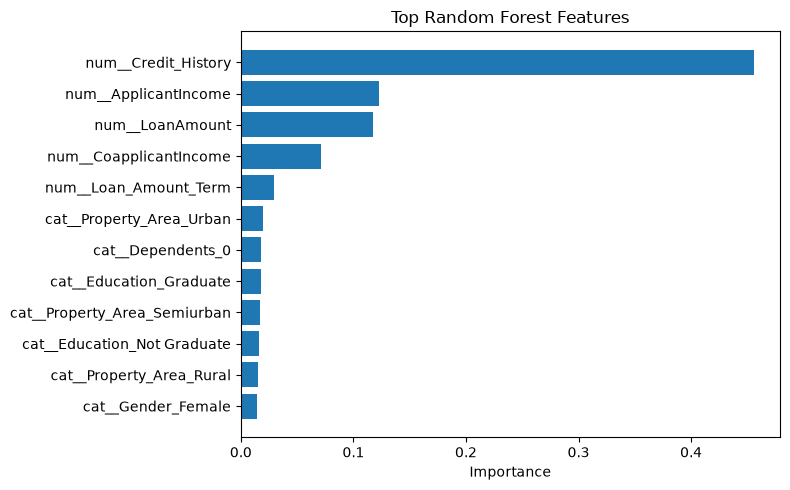

In [27]:
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(12)
)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top Random Forest Features")
plt.tight_layout()
plt.savefig("outputs/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## Conclusion

- Missing categorical values are filled with the most frequent category.
- Missing numeric values are filled with the median.
- Categorical variables are converted using one-hot encoding.
- Both Decision Tree and Random Forest are evaluated on the same test set.
- Random Forest is generally more robust because it combines many decision trees.
- Feature importance helps identify which application attributes contribute most to the model's decisions.

> This project is for ML learning/assignment purposes and should not be used as a real-world lending decision system.
